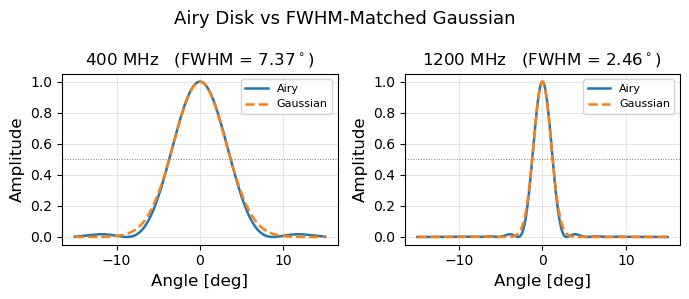

In [3]:
"""Compare the Airy (uniform-illumination) primary beam against a FWHM-matched
Gaussian for a 6 m dish at 400 MHz and 1200 MHz."""
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

sol = 3e8  # speed of light [m/s], matches constants.C

def airy_beam(a, D, freq):
    # angle in deg, D in m, freq in MHz
    a = np.abs(a)
    arad = a * np.pi / 180
    wavelength = sol * 1e-6 / freq
    ap = np.pi * D * np.sin(arad) / wavelength
    with np.errstate(invalid="ignore", divide="ignore"):
        out = np.where(
            a < 180,
            np.where(ap > 1e-30, (2 * jv(1, ap) / ap) ** 2, (jv(0, ap) - jv(2, ap)) ** 2),
            0,
        )
    return out

def gaussian_beam(a, D, freq):
    # FWHM-matched Gaussian, peak 1. theta_FWHM = 1.029 * lambda / D (in radians).
    wavelength = sol * 1e-6 / freq
    fwhm_deg = np.degrees(1.029 * wavelength / D)
    return np.exp(-4 * np.log(2) * (a / fwhm_deg) ** 2)


D = 6.0  # m
freqs = [400, 1200]  # MHz
a = np.linspace(-15, 15, 4001)  # deg

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for col, f in enumerate(freqs):
    airy = airy_beam(a, D, f)
    gauss = gaussian_beam(a, D, f)
    wavelength = sol * 1e-6 / f
    fwhm_deg = np.degrees(1.029 * wavelength / D)

    # linear
    ax = axes[col]
    ax.plot(a, airy, label="Airy", lw=1.8)
    ax.plot(a, gauss, "--", label="Gaussian", lw=1.8)
    ax.axhline(0.5, color="grey", lw=0.7, ls=":")
    ax.set_title(f"{f} MHz   (FWHM = {fwhm_deg:.2f}$^\\circ$)", fontsize=12)
    ax.set_ylabel("Amplitude", fontsize=12)
    ax.set_xlabel("Angle [deg]", fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


fig.suptitle("Airy Disk vs FWHM-Matched Gaussian", fontsize=13)
fig.tight_layout()
path = "../../thesis/plots/sensitivity/airy_vs_gaussian.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
